# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterHierarchicalModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [7]:
features_not_considered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [8]:
helper = cluster.HierarchicalClusterHelper(data=data_covid, features_not_considered=features_not_considered)

2026-02-19 18:38:07,341 - ClusterBaseModule - INFO - ClusterBaseHelper initialized: 3355 records, 67 features (22 categorical, 51 numerical)


## Find best hyperparameters for hierarchical clustering

In [9]:
param_grid = {
    "linkage_methods": ["ward", "complete", "average", "single"],
    "distance_metrics": ["euclidean"],
    "random_state": [42],
}

Linkage Methods:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

2026-02-19 18:39:14,666 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 18:39:19,547 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.028, dbcv=-0.998, dsi=0.100, disco=0.003
2026-02-19 18:39:19,746 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-19 18:39:24,329 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.030, dbcv=-0.995, dsi=0.152, disco=0.007
2026-02-19 18:39:24,524 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 4 clusters
2026-02-19 18:39:29,606 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.018, dbcv=-0.994, dsi=0.125, disco=0.002
2026-02-19 18:39:29,891 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 5 clusters
2026-02-19 18:39:34,691 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-0.090, dbcv=-0.992, dsi=0.166, disco=-0.047
2026-02-19 18:39:34,888 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 6 clusters


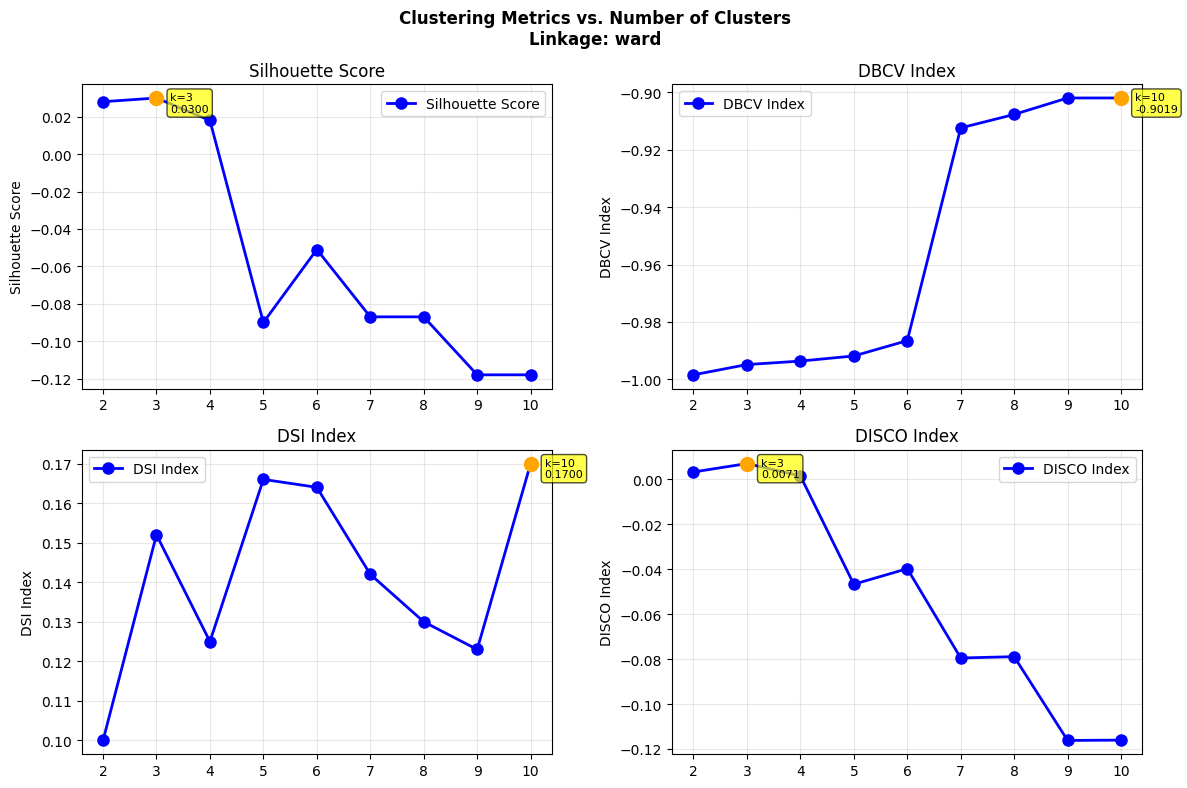

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

2026-02-19 18:39:59,763 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 18:40:04,986 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.974, dbcv=1.000, dsi=0.749, disco=0.994
2026-02-19 18:40:05,182 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-19 18:40:10,647 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-0.099, dbcv=1.000, dsi=0.411, disco=-0.045
2026-02-19 18:40:10,841 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 4 clusters
2026-02-19 18:40:16,571 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-0.105, dbcv=1.000, dsi=0.303, disco=-0.045
2026-02-19 18:40:16,769 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 5 clusters
2026-02-19 18:40:22,174 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-0.095, dbcv=1.000, dsi=0.340, disco=0.003
2026-02-19 18:40:22,368 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 6 clusters
2

<Figure size 640x480 with 0 Axes>

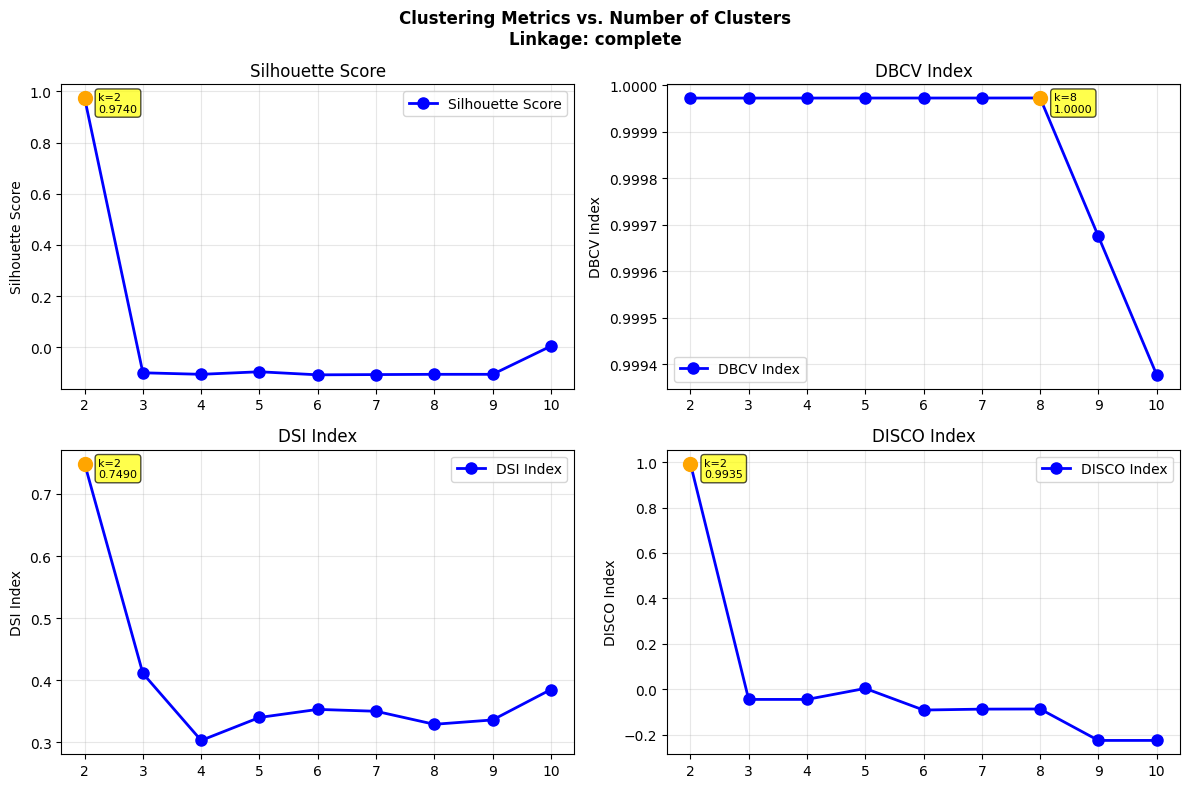

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

2026-02-19 18:40:50,635 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 18:40:55,876 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.974, dbcv=1.000, dsi=0.749, disco=0.994
2026-02-19 18:40:56,068 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-19 18:41:01,528 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.973, dbcv=1.000, dsi=0.749, disco=0.121
2026-02-19 18:41:01,721 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 4 clusters
2026-02-19 18:41:06,959 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.973, dbcv=0.999, dsi=0.749, disco=-0.268
2026-02-19 18:41:07,152 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 5 clusters
2026-02-19 18:41:12,440 - ClusterBaseModule - INFO - Calculated metrics: silhouette=0.938, dbcv=0.999, dsi=0.665, disco=-0.235
2026-02-19 18:41:12,640 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 6 clusters
2026

<Figure size 640x480 with 0 Axes>

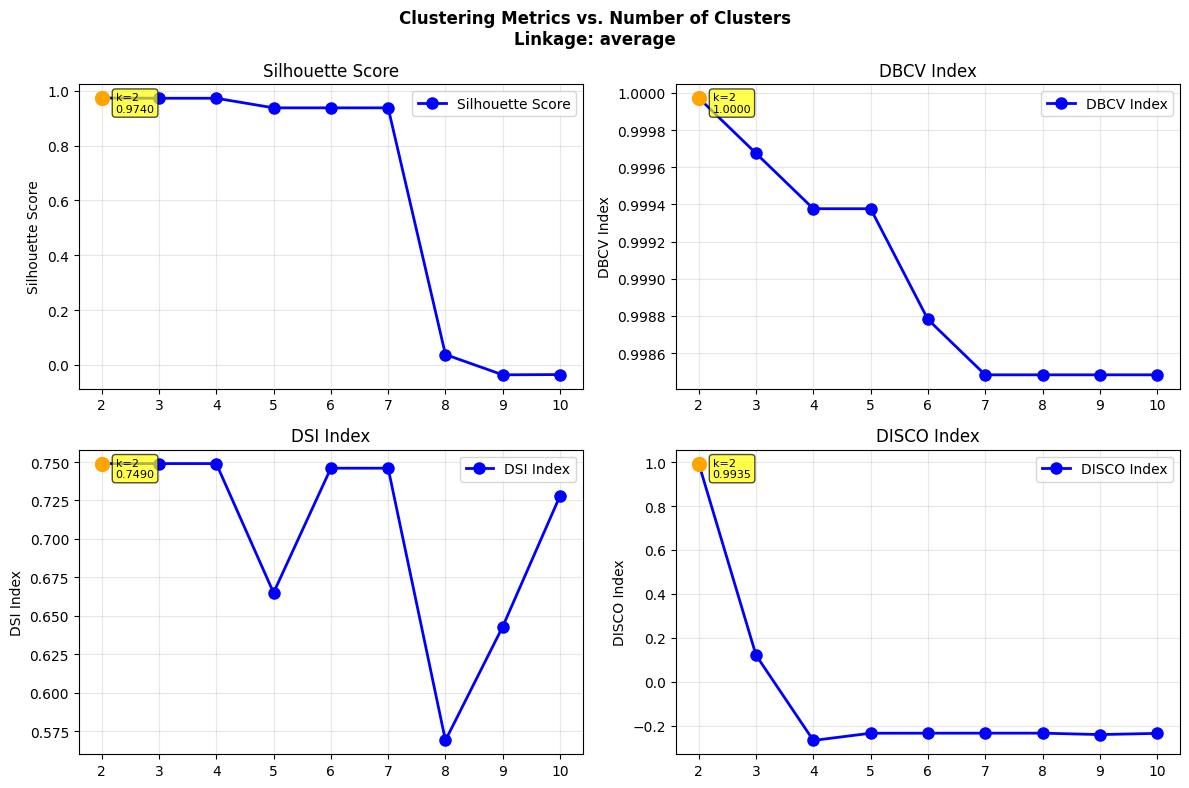

Calculating metrics per k:   0%|          | 0/9 [00:00<?, ?it/s]

2026-02-19 18:41:40,550 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 2 clusters
2026-02-19 18:41:43,906 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-1.000, dbcv=1.000, dsi=0.000, disco=0.996
2026-02-19 18:41:44,096 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 3 clusters
2026-02-19 18:41:47,579 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-1.000, dbcv=0.999, dsi=0.000, disco=0.989
2026-02-19 18:41:47,777 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 4 clusters
2026-02-19 18:41:51,164 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-1.000, dbcv=0.999, dsi=0.000, disco=0.121
2026-02-19 18:41:51,353 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 5 clusters
2026-02-19 18:41:54,906 - ClusterBaseModule - INFO - Calculated metrics: silhouette=-1.000, dbcv=0.999, dsi=0.000, disco=-0.267
2026-02-19 18:41:55,096 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 6 clusters
2

<Figure size 640x480 with 0 Axes>

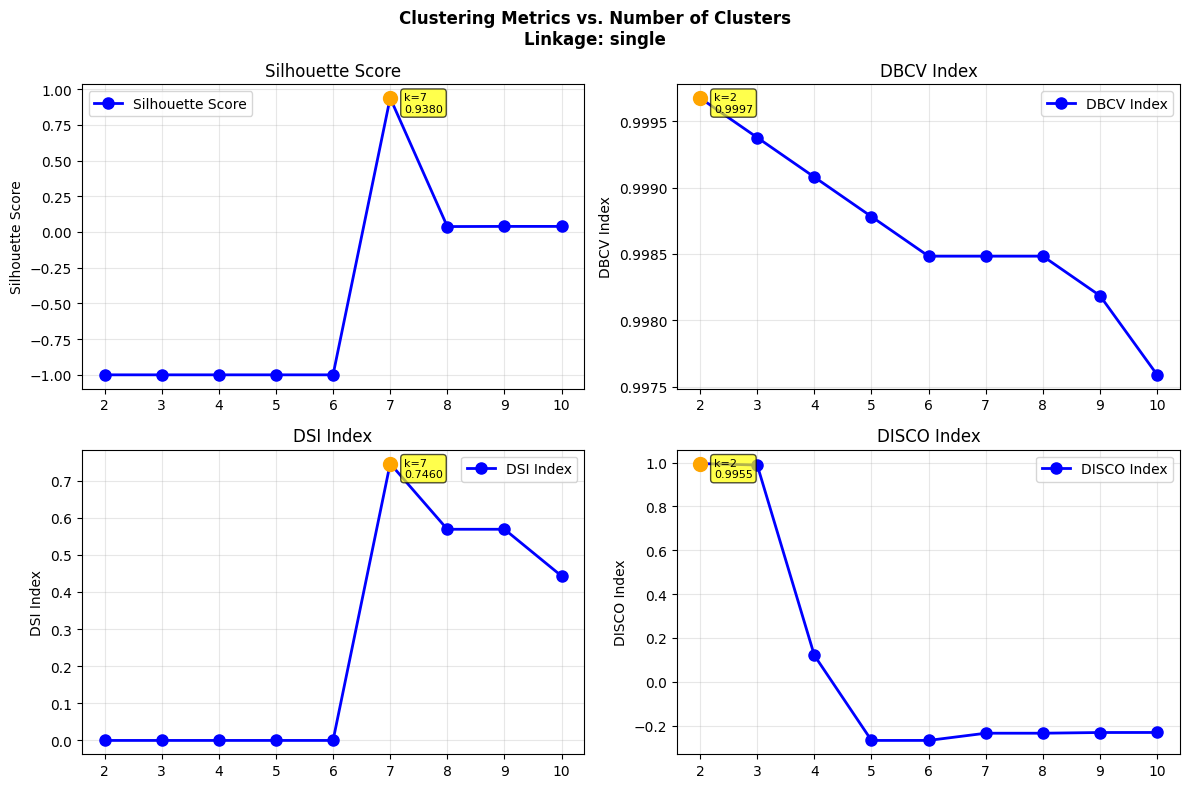

""


<Figure size 640x480 with 0 Axes>

In [10]:
os.environ["PYTHONWARNINGS"] = "ignore"
helper.grid_search_linkage_methods(param_grid["linkage_methods"], figsize=(12,8))

## Dendogram

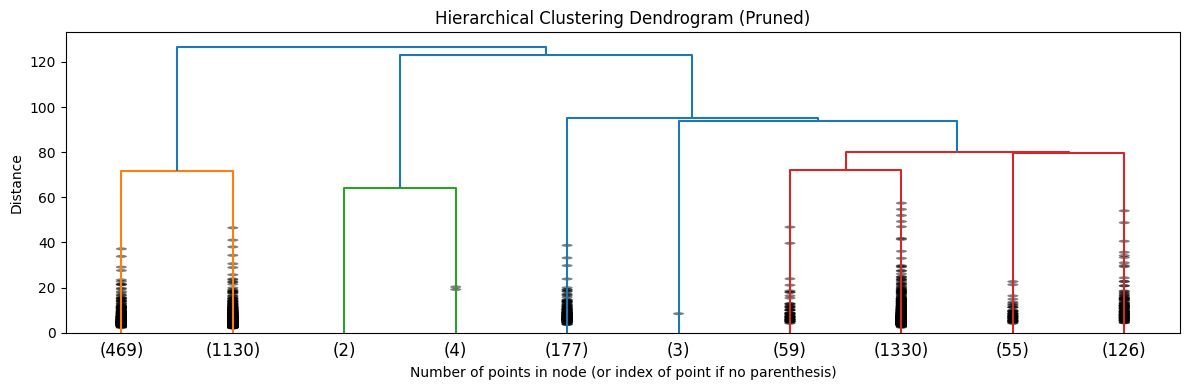

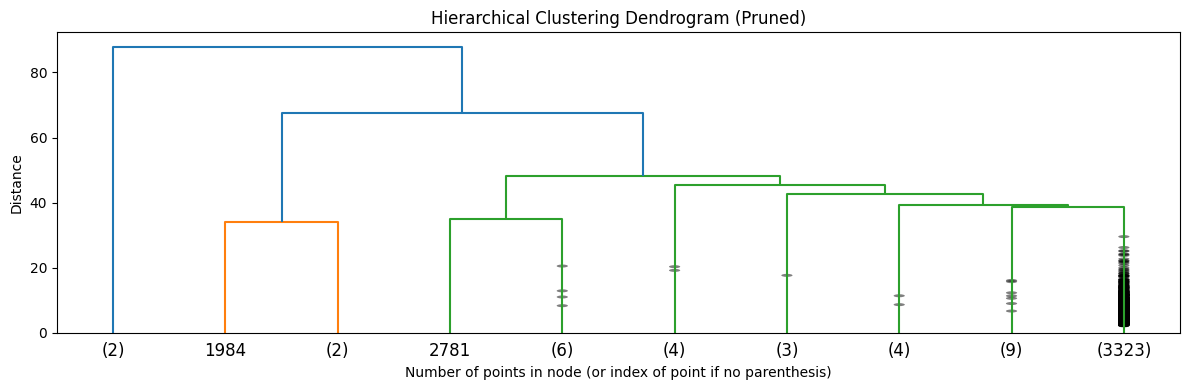

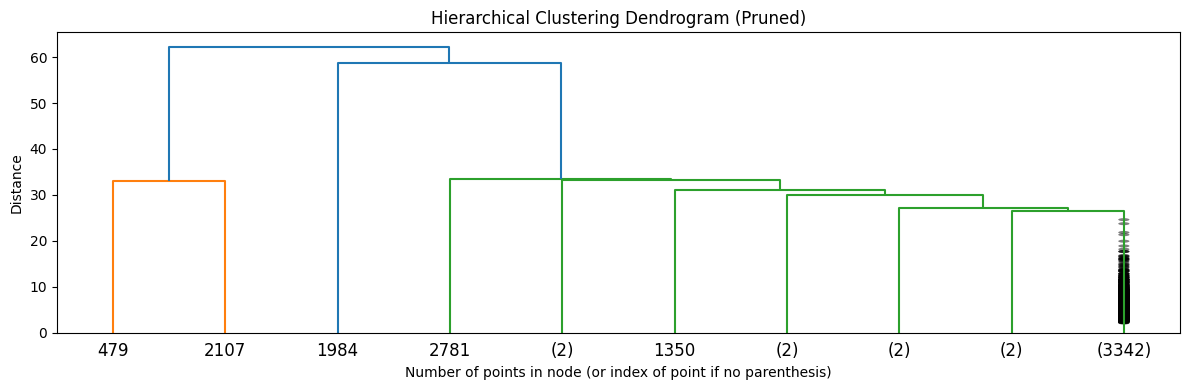

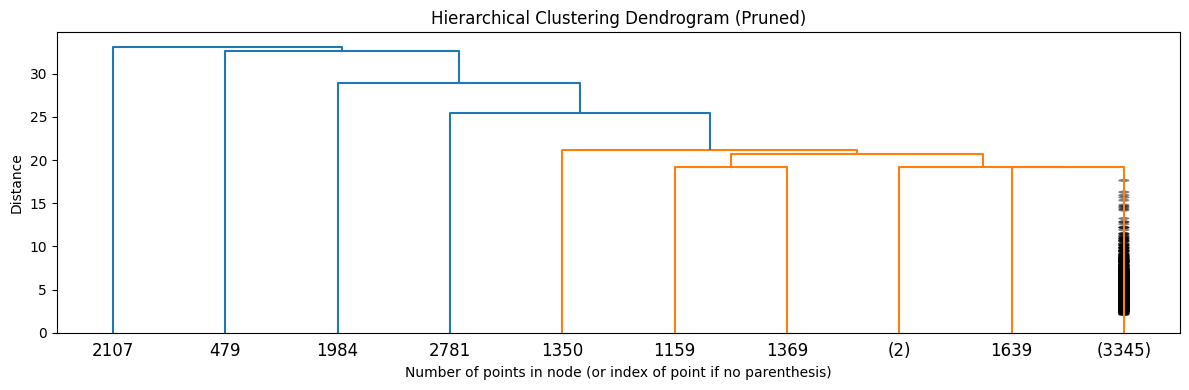

In [11]:
linkage_methods = ["ward", "complete", "average", "single"]

for linkage in linkage_methods:
    helper.plot_dendrogram(
        max_children=10,
        figsize=(12, 4),
        linkage_method=linkage,
    )


### Ward - Euclidean

#### K = 10

2026-02-19 18:45:44,838 - ClusterBaseModule - INFO - Clustered data set: 3355 records, 10 clusters
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:474: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_stats = self._clustered_data.groupby("Cluster").apply(calculate_stats).T
2026-02-19 18:45:44,851 - ClusterBaseModule - INFO - Calculated categorical stats for 10 clusters
/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/ClusterBaseModule.py:1448: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.97 x' has dtype incompatible with float64, please explicitly cast to a compatible dt

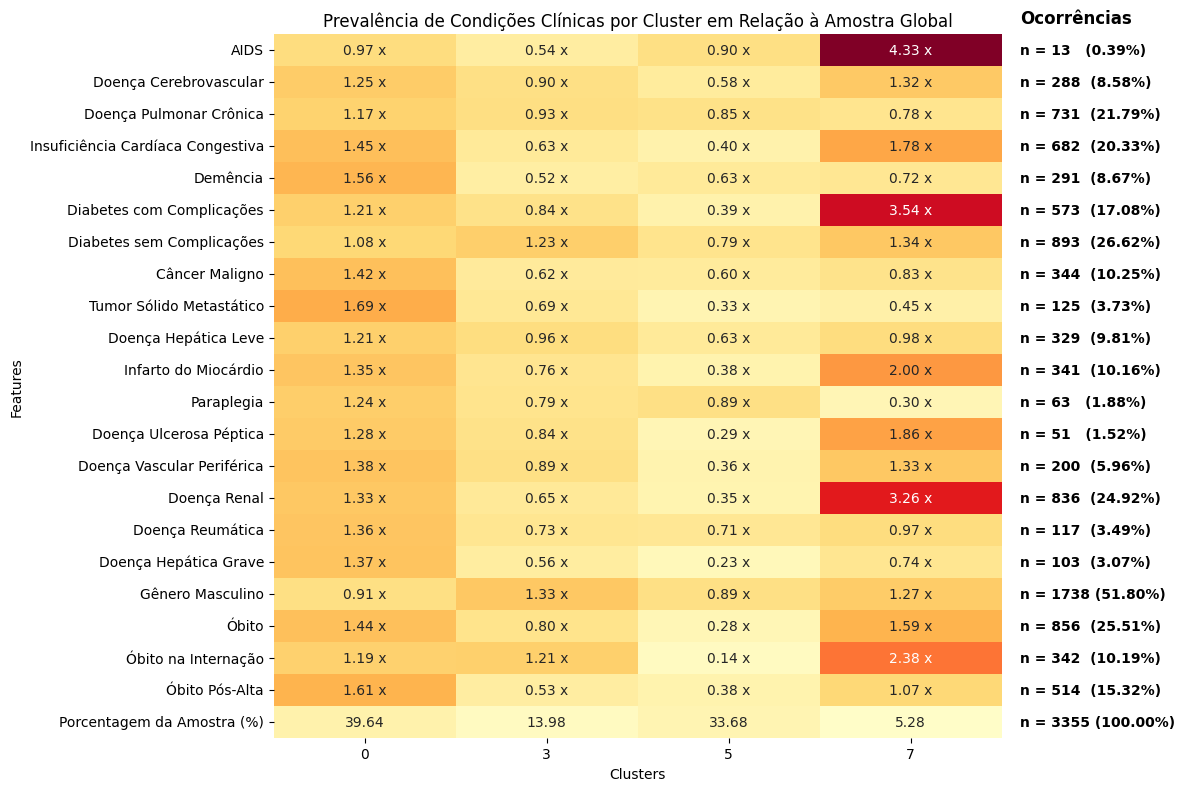

2026-02-19 18:45:45,021 - ClusterBaseModule - INFO - Created categorical heatmap: 22 features, 4 clusters


In [13]:
mice_cluster = helper.clustering(n_clusters=10, linkage_method="ward")
helper.heatmap_clusters_categorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    relative_total=True,
    # savepath=IMAGES_SAVE_PATH + "hierarchical-all-categorical",
)

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/sklearn/utils/v

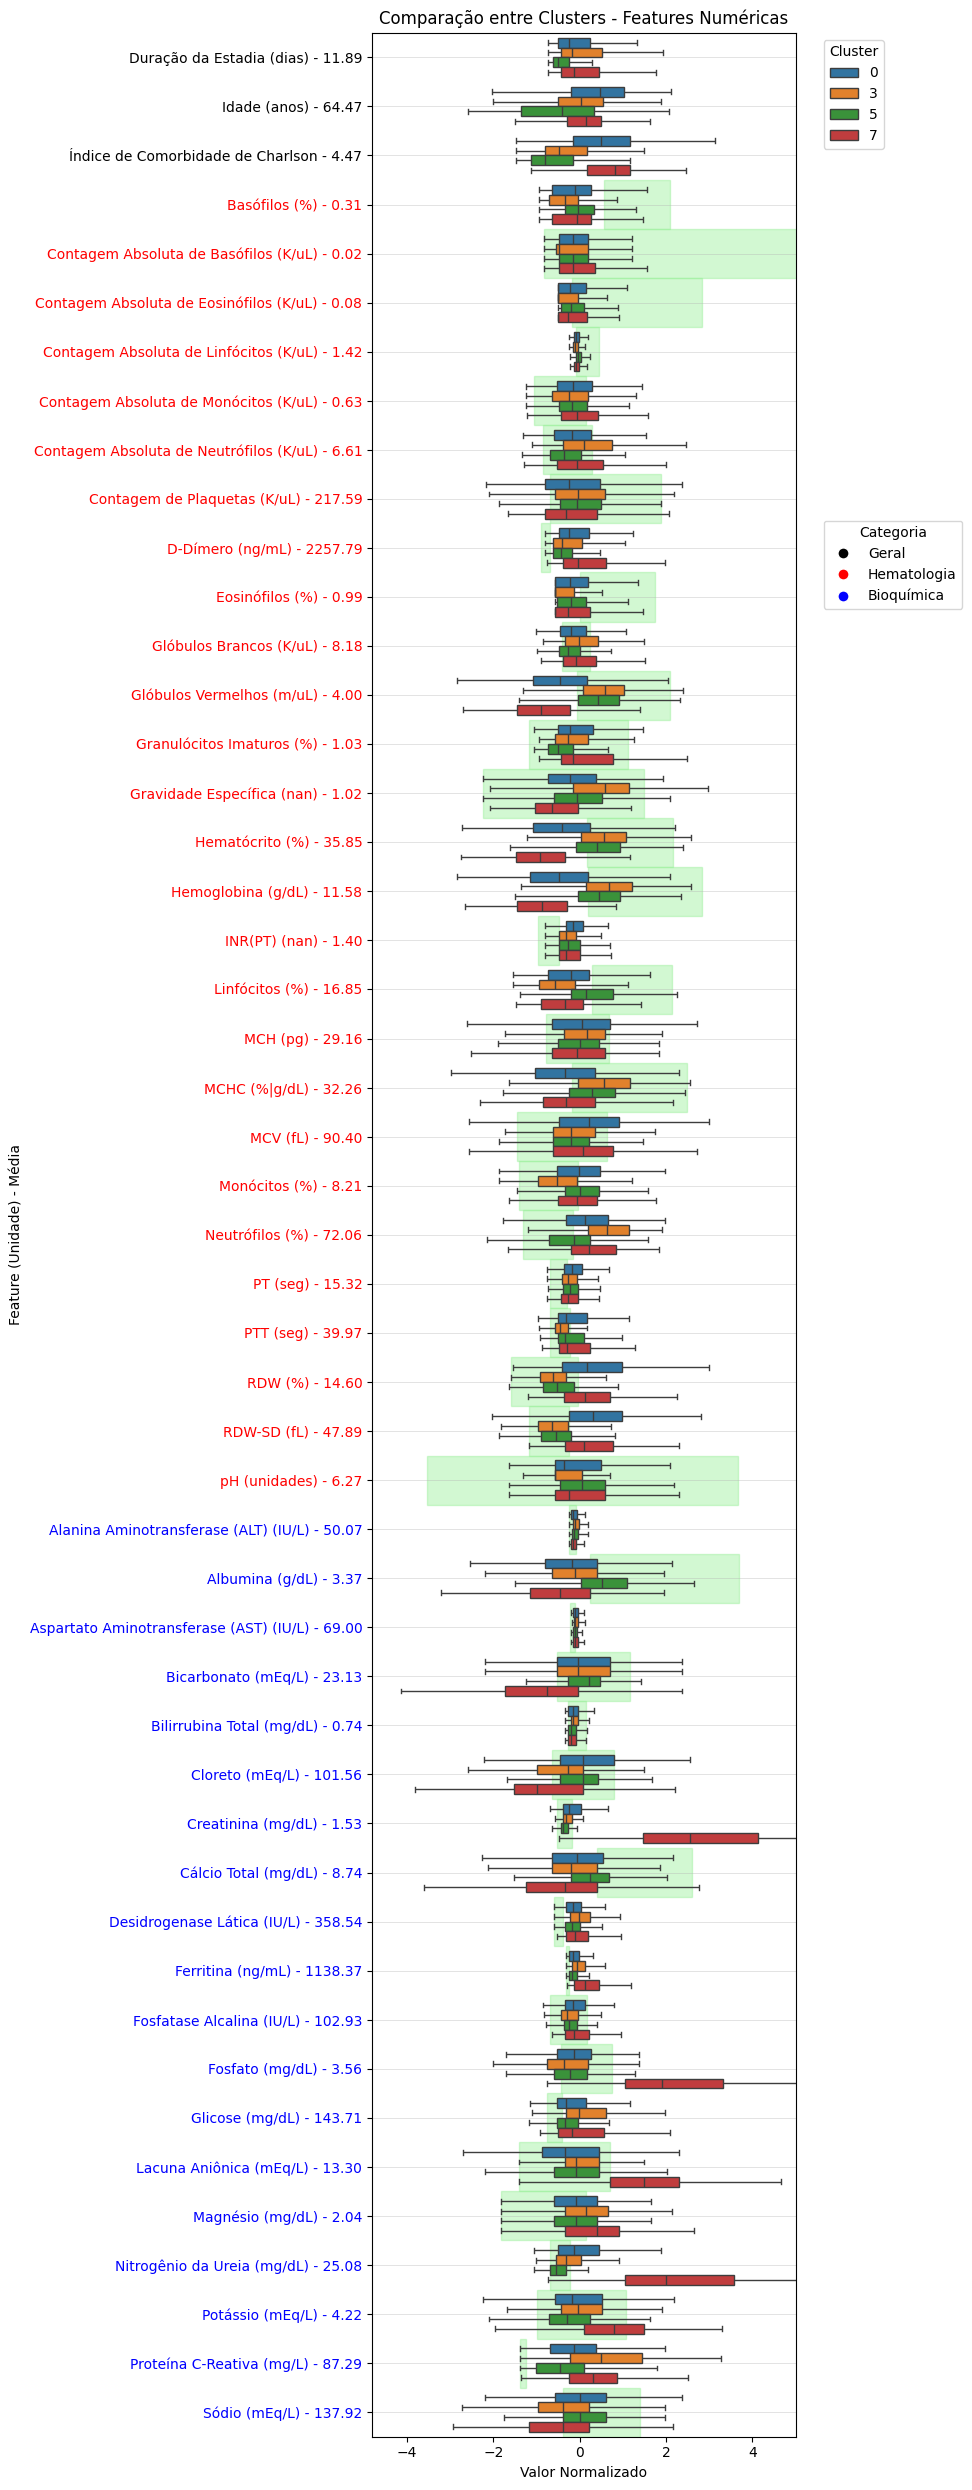

2026-02-19 18:46:41,368 - ClusterBaseModule - INFO - Displayed numerical comparison: 49 features, 4 clusters


[]

In [16]:
helper.show_cluster_compare_numerical(
    figsize=(10, 25),
    # savepath=IMAGES_SAVE_PATH + "hierarchical-all-numerical",
)

In [17]:
selected_clusters = [0, 3, 5, 7]

In [18]:
helper.set_clustered_autoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.07it/s]


2026-02-19 18:47:36,296 - ClusterBaseModule - INFO - Autoencoder clustering completed: 3355 records, embedding_size=2


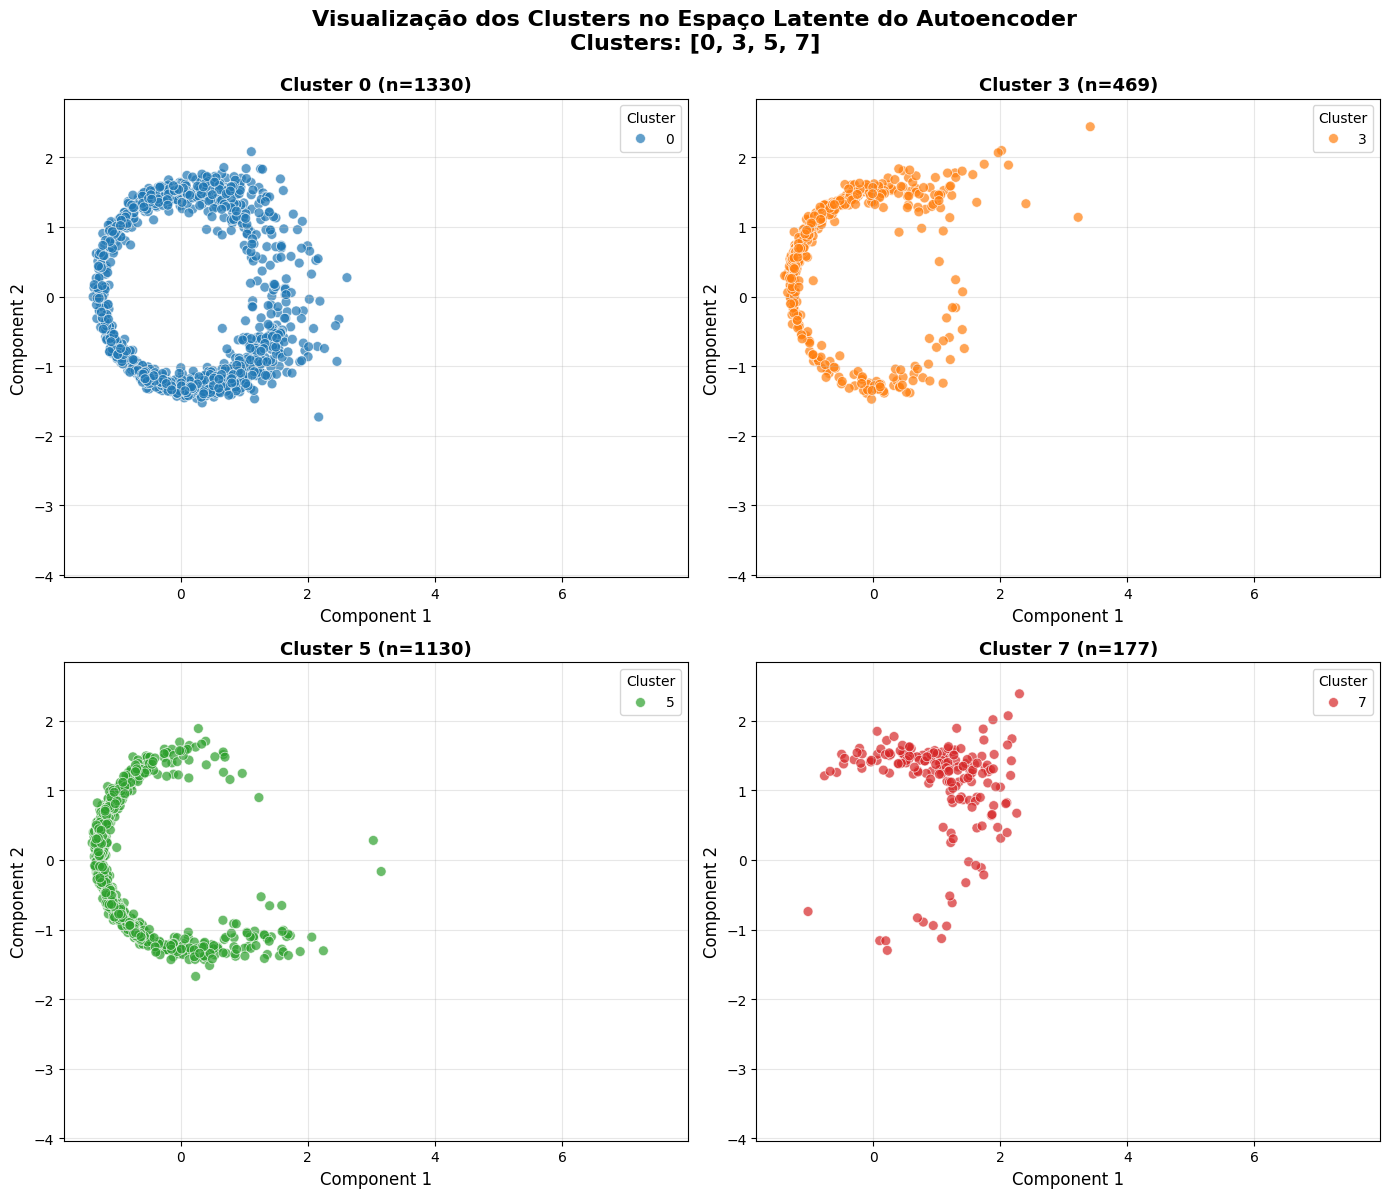

2026-02-19 18:47:36,572 - ClusterBaseModule - INFO - Displayed autoencoder clusters: 4 clusters


In [19]:
helper.show_clustered_autoencoder(
    selected_clusters=selected_clusters,
    # savepath=IMAGES_SAVE_PATH + "hierarchical-autoencoder-all",
)

##### Future data


/Users/gabrielleite/Backup/Mestrado/Mestrado-COVID/Modules/FutureAnalysisModule.py:35: UserWarning: Warning: Some subject_ids in futureData are missing from pastData.
  warnings.warn(


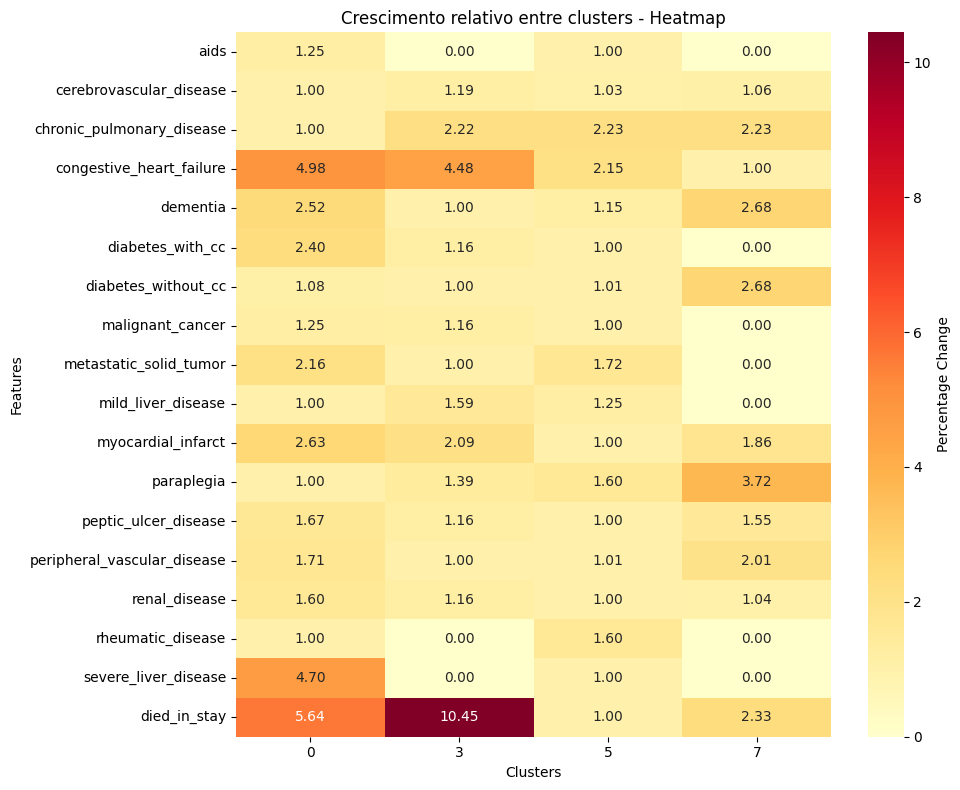

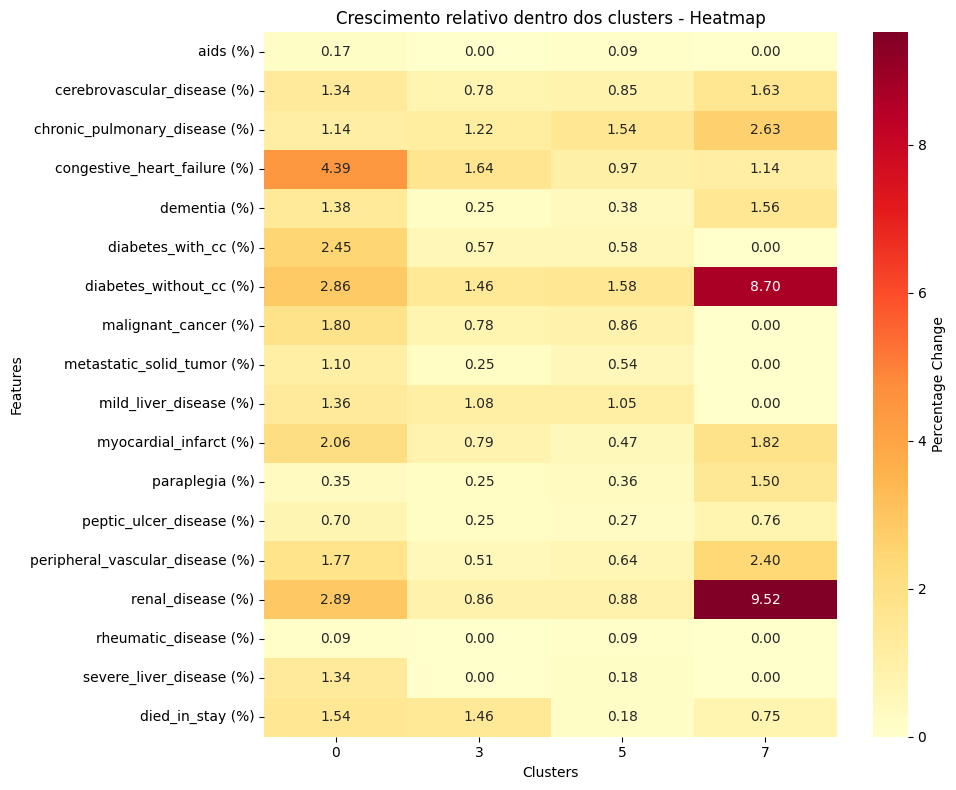

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clustered_data, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selected_clusters,
    # savepath=IMAGES_SAVE_PATH + "kmeans-all-future",
)

In [ ]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster 0': 2.6,
 'Mean readmission Cluster 1': 2.59,
 'Mean readmission Cluster 2': 2.19,
 'Mean readmission Cluster 3': 2.05,
 'Mean readmission Cluster 4': 2.0,
 'Mean readmission Cluster 5': 1.92,
 'Mean readmission Cluster 6': 2.35,
 'Mean readmission Cluster 7': 2.31,
 'Mean readmission Cluster 8': 2.0,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster 0': 121.52,
 'Mean days gap Cluster 1': 113.6,
 'Mean days gap Cluster 2': 60.73,
 'Mean days gap Cluster 3': 132.49,
 'Mean days gap Cluster 4': 40.08,
 'Mean days gap Cluster 5': 138.65,
 'Mean days gap Cluster 6': 89.72,
 'Mean days gap Cluster 7': 165.76,
 'Mean days gap Cluster 8': 45.82,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster 0': 0.11,
 'Mortality rate Cluster 1': 0.25,
 'Mortality rate Cluster 2': 0.02,
 'Mortality rate Cluster 3': 0.1,
 'Mortality rate Cluster 4': 0.0,
 'Mortality rate Cluster 5': 0.12,
 'Mortality rate Cluster 6': 0.12,
 'Mortality rate Cluster 7': 0.02,
 'Mortality rate Cluster 8': 0.0,
 'Overall Mortality rate': 0.09}

# Add log

In [ ]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"Hierarchical, None, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
